In [1]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from kuramoto.config import (
    SimulationConfig,
    GridConfig,
    CouplingConfig,
    InitThetaConfig,
    InitOmegaConfig,
    KernelComponentConfig,
    build_simulation,
    get_components_bottleneck,
    get_groupids_bottleneck,
    get_components_unstructured,
    get_groupids_unstructured,
)
from kuramoto.adjoint import grads_final_R, grads_mean_R
from kuramoto.plotting import plot_2d
from kuramoto.network import (
    create_cortical_graph,
    plot_cortical_graph,
    get_degree,
    get_deg_centrality,
    get_closeness_centrality,
    get_betweenness_centrality,
    get_eigenvector_centrality,
)

SEED = 42
grid_shape = (12, 12)
T_END = 10.0
dt = 0.01

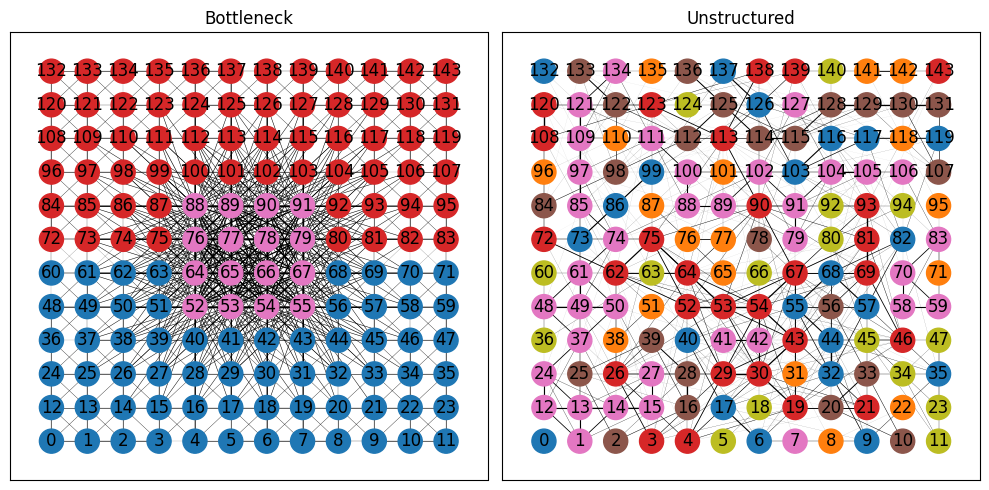

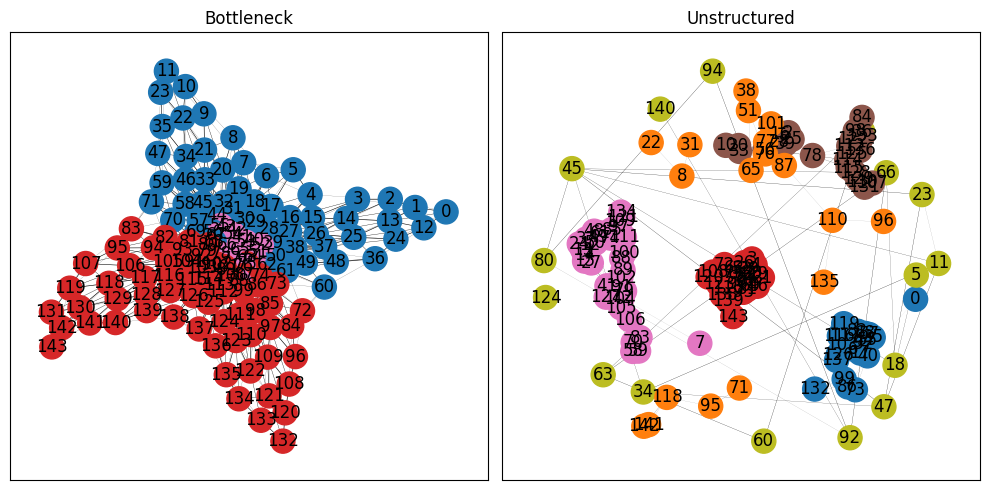

In [2]:
# Bottleneck case
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(
        mode="spatial",
        components=get_components_bottleneck(seed=42),
        group_ids=get_groupids_bottleneck(grid_shape),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_bottleneck = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_bottleneck = create_cortical_graph(sim_bottleneck)

# Unstructured case
N_GROUPS = 6
cfg = SimulationConfig(
    grid=GridConfig(shape=grid_shape, periodic=False),
    coupling=CouplingConfig(mode="full", 
                    components=get_components_unstructured(n_groups=N_GROUPS, seed=42, k_factor=1.0), 
                    group_ids=get_groupids_unstructured(grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(42)),
    ),
    initial_theta=InitThetaConfig(mode="uniform"),
    initial_omega=InitOmegaConfig(mode="normal", mu=0.0, sigma=0.3),
    seed=42,
)
sim_unstructured = build_simulation(config=cfg, rng=np.random.default_rng(42))
G_unstructured = create_cortical_graph(sim_unstructured)

# Show graph structure
fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="grid", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="grid", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
plot_cortical_graph(G_bottleneck, layout="spring", ax=axs[0])
axs[0].set_title("Bottleneck")
plot_cortical_graph(G_unstructured, layout="spring", ax=axs[1])
axs[1].set_title("Unstructured")
plt.tight_layout()
plt.show()

### 1) Evaluate R and Rlink with varying k

In [30]:
Kf_list = np.arange(0.05, 2.0, 0.05)

T_END = 10

case_results = {
    "bottleneck": {
        "Kf": Kf_list,
        "Rm": [],
        "R_link": [],
        "R_t": [],
    },
    "unstructured": {
        "Kf": Kf_list,
        "Rm": [],
        "R_link": [],
        "R_t": [],
    }
}

R_list = []
R_link_list = []
for Kf in Kf_list:
    cfg_bottleneck = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            mode="spatial",
            components=get_components_bottleneck(seed=42, k_factor=Kf),
            group_ids=get_groupids_bottleneck(grid_shape),
        ),
        seed=42,
    )
    sim_bottleneck = build_simulation(config=cfg_bottleneck, rng=np.random.default_rng(42))
    results_bottleneck = sim_bottleneck.run((0, T_END), dt, rng=np.random.default_rng(42), postprocess=True)

    case_results["bottleneck"]["Rm"].append(results_bottleneck['Rm'])
    case_results["bottleneck"]["R_t"].append(results_bottleneck['R'])
    case_results["bottleneck"]["R_link"].append(results_bottleneck['R_link'])

    # Unstructured case
    cfg_unstructured = SimulationConfig(
        grid=GridConfig(shape=grid_shape, periodic=False),
        coupling=CouplingConfig(
            mode="full",
            components=get_components_unstructured(n_groups=N_GROUPS, seed=42, k_factor=Kf),
            group_ids=get_groupids_unstructured(grid_shape, n_groups=N_GROUPS, rng=np.random.default_rng(42)),
        ),
        seed=42,
    )
    sim_unstructured = build_simulation(config=cfg_unstructured, rng=np.random.default_rng(42))
    results_unstructured = sim_unstructured.run((0, T_END), dt, rng=np.random.default_rng(42), postprocess=True)

    case_results["unstructured"]["Rm"].append(results_unstructured['Rm'])
    case_results["unstructured"]["R_t"].append(results_unstructured['R'])
    case_results["unstructured"]["R_link"].append(results_unstructured['R_link'])

C:\Users\Adam\AppData\Local\Temp\ipykernel_32972\4196757674.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('viridis')


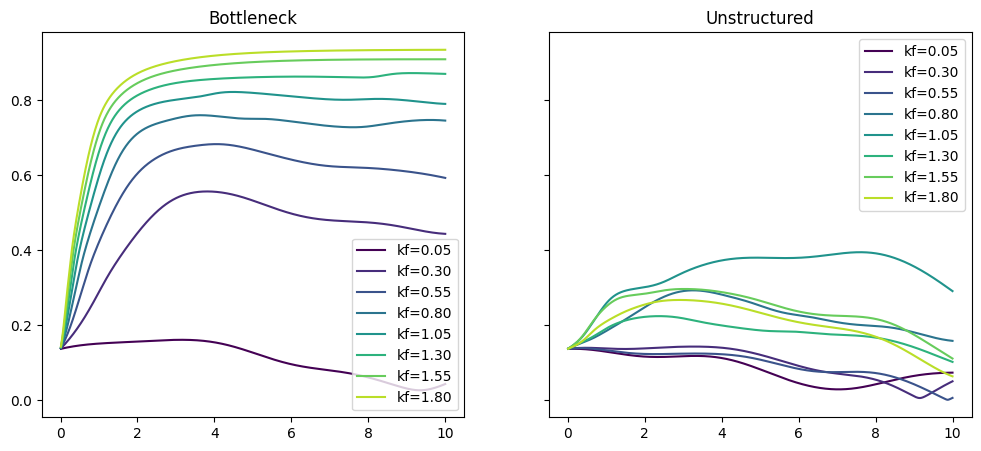

In [34]:
ts = results_bottleneck['ts']
# Transient plots
cmap = plt.cm.get_cmap('viridis')

fig,axs = plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=True)
Rm_t_bottleneck = case_results["bottleneck"]["R_t"]
Rm_t_unstructured = case_results["unstructured"]["R_t"]

stride = 5
for i, (kf, Rt1, Rt2) in enumerate(zip(Kf_list[::stride], Rm_t_bottleneck[::stride], Rm_t_unstructured[::stride])):
    c = cmap(i*stride/len(Rm_t_bottleneck))
    axs[0].plot(ts, Rt1, color=c, label=f"kf={kf:.2f}")
    axs[1].plot(ts, Rt2, color=c, label=f"kf={kf:.2f}")
    
axs[0].set_title("Bottleneck")
axs[0].legend()
axs[1].set_title("Unstructured")
axs[1].legend()

Text(0, 0.5, 'R')

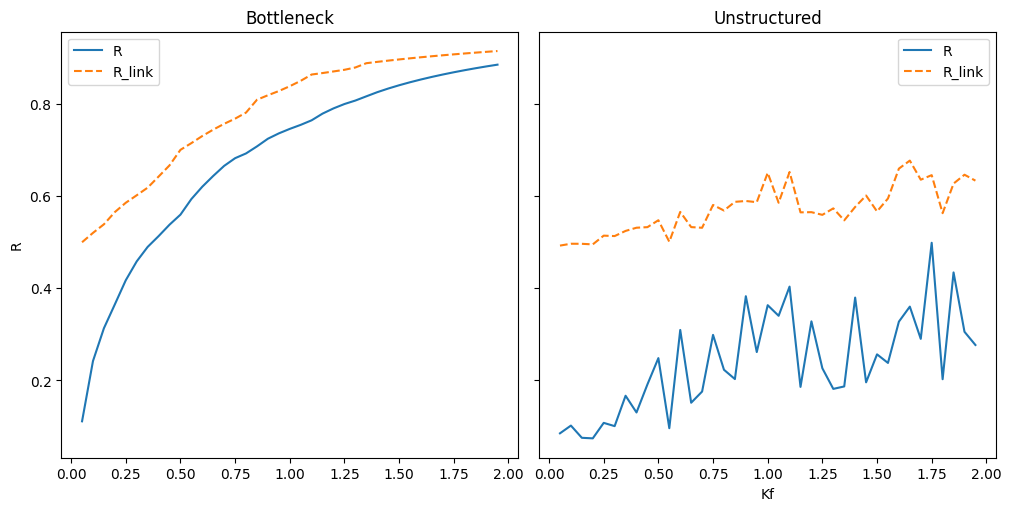

In [35]:
fig, axs = plt.subplots(1, 2, figsize=(10, 5), sharex=True,sharey=True, constrained_layout=True)
axs[0].plot(case_results["bottleneck"]["Kf"], case_results["bottleneck"]["Rm"], label="R")
axs[0].plot(case_results["bottleneck"]["Kf"], case_results["bottleneck"]["R_link"], ls="--", label="R_link")
axs[0].set_title("Bottleneck")
axs[0].legend()

axs[1].plot(case_results["unstructured"]["Kf"], case_results["unstructured"]["Rm"], label="R")
axs[1].plot(case_results["unstructured"]["Kf"], case_results["unstructured"]["R_link"], ls="--", label="R_link")
axs[1].set_title("Unstructured")
axs[1].legend()
axs[1].set_xlabel("Kf")
axs[0].set_ylabel("R")